## Notebook 7 — Penman-Monteith `Kc` Calibration

Notebook 04 tests whether a simple multiplicative PET calibration can close
most of the accuracy gap between default (uncalibrated) Oudin and default
(uncalibrated) Penman-Monteith. That comparison, however, only calibrates one
side of it: Penman-Monteith has always been run with an uncalibrated crop
coefficient (`Kc = 1.0`, notebook 06's baseline), so it has never been given
the same chance to improve that Oudin has.

**This notebook closes that gap.** `wbm.nps_wbm()`'s `pet_mult` argument is a
generic multiplicative adjustment applied to whatever the chosen `pet_method`
returns, before it drives soil moisture and AET -- for Oudin it acts as a PET
multiplier, for Penman-Monteith it *is* the crop coefficient `Kc`
(`PET = Kc × ETo`). Calibrating `Kc` against OpenET is therefore
mechanically identical to notebook 04's Oudin calibration, just with
`pet_method` fixed to `"Penman-Monteith"` -- same objective functions, same
2016–2021 / 2022–2023 calibration / held-out split, same per-site and
per-ecosystem granularity, and the same incremental-caching pattern.

**Two variants, mirroring notebook 04:**
1. **Per-site calibrated Penman-Monteith** -- one `Kc` fit per site.
2. **Per-ecosystem calibrated Penman-Monteith** -- one pooled `Kc` per
   ecosystem type (all sites of a land-cover class fit together as a single
   objective).

**Why this matters:** if calibrated Penman-Monteith turns out to be
significantly more accurate than calibrated Oudin, that changes the
nationwide-default recommendation -- right now uncalibrated Penman-Monteith
is recommended for current-condition assessments partly *because* it needs
no site-specific calibration data, but if a cheap `Kc` calibration closes
most of its remaining gap with calibrated Oudin, that tips the balance
further in its favor. If it doesn't help much, that's useful negative
evidence that Penman-Monteith's accuracy is already close to its physical
ceiling. Either way, this does **not** change Penman-Monteith's fundamental
limitation for future-climate work: it still needs real wind speed, which
downscaled climate projections don't reliably provide, so this calibration
only benefits current-condition and historical assessments -- the same
restriction that already applies to the uncalibrated run.

**Scope / assumptions:**
- Same snow/soil/runoff parameters as every other WBM run in this repo
  (`HOCK_COEF`, `DIRECT_FRAC`, `RETURN_RATE`, `SOIL_MULT`, `SHADE_COEFF`,
  `T_BASE`) -- only `Kc` varies, so any accuracy difference from notebook 06's
  uncalibrated Penman-Monteith run is attributable to the calibration alone.
- Vapor pressure still falls back to the conservative `e_a = e_tmin`
  approximation (no gridMET relative humidity pulled into this repo yet --
  see notebook 06's banner); the calibrated `Kc` partly absorbs whatever bias
  that fallback introduces, so this isn't a calibration of "true"
  Penman-Monteith error in isolation.
- This notebook only reads cached CSVs from notebooks 01/02 and re-runs the
  WBM locally -- no Earth Engine access needed (rasters and gridMET/OpenET
  pulls are already cached).

**Prerequisites:** run notebooks 01→02 at least once (site list, gridMET
climate with `wind_ms`, and OpenET gridcell cache).

# Setup Workspace

Imports, WBM package, and raster loading -- no GEE authentication needed
(this notebook only reads already-cached data and re-runs the WBM
locally).

In [1]:
# ── Make the repo root (parent of notebooks/) importable ─────────────────────
import sys
from pathlib import Path as _Path
_REPO_ROOT = _Path.cwd().parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

import importlib
import wbm
importlib.reload(wbm)
from wbm import load_wbm_rasters, extract_point_params, nps_wbm

pd.set_option("display.width", 120)
print("Imports OK -- this notebook only reads cached CSVs and re-runs the WBM locally, no GEE access needed.")


Imports OK -- this notebook only reads cached CSVs and re-runs the WBM locally, no GEE access needed.


Load WBM rasters (needed by `extract_point_params()` to sample site
parameters -- same rasters every other notebook uses, no re-download).

In [2]:
RASTER_DIR = "../Data/wbm_rasters"
TARGET_CRS = "EPSG:4326"

try:
    load_wbm_rasters(raster_dir=RASTER_DIR, target_crs=TARGET_CRS)
    print("Rasters loaded.")
except (ImportError, FileNotFoundError) as e:
    print(f"WARNING -- rasters not loaded: {e}")


Loading WBM rasters from '../Data/wbm_rasters' ...
  DEM loaded        : (2733, 4381)  CRS=PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6378137,298.25723]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",42.5],PARAMETER["central_meridian",-100],PARAMETER["standard_parallel_1",25],PARAMETER["standard_parallel_2",60],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Soil loaded       : (3620, 5769)  CRS=EPSG:5070
  Jennings loaded   : (142, 576)  CRS=EPSG:4326
  Reprojecting DEM → EPSG:4326 ...


/Users/kcognac/Desktop/Repositories/WBM_ET_Exploration/wbm/raster_io.py:259: RasterioDeprecationWarning: is_valid is not useful and will be removed in 2.0.0.
  if jtemp_crs is None or not jtemp_crs.is_valid:


  Reprojecting Soil → EPSG:4326 ...
  Computing slope & aspect (Horn's method) ...
  ✓ All rasters loaded and cached.

Rasters loaded.


Global model settings -- identical snow/soil/runoff parameters to every
other WBM run in this repo (notebooks 03/04/06), so any AET difference traces
back to the PET method and its calibration alone. `pet_method` is fixed to
`"Penman-Monteith"` explicitly in the run function below rather than set
here, to avoid any risk of this notebook accidentally running with the wrong
global default.

In [3]:
HOCK_COEF   = 4.0     # degree-day melt factor (mm C-1 day-1)
DIRECT_FRAC = 0.0     # fraction of rainfall routed directly to runoff
RETURN_RATE = 1.0     # fraction of storage reservoir released per day
SOIL_MULT   = 1.0     # multiplicative adjustment to SWC_Max
SHADE_COEFF = 1.0     # canopy shading coefficient (unused by Penman-Monteith, kept for parity)
T_BASE      = 0.0     # base temperature for growing degree days (C)
TO_INCHES   = True    # match the repo-wide convention (notebooks 03/04/06)

print("Model settings configured (pet_method='Penman-Monteith' fixed in run_wbm_with_spinup_pm below):")
print(f"  Hock coef    : {HOCK_COEF} mm/C/day")
print(f"  Direct frac  : {DIRECT_FRAC}  |  Return rate: {RETURN_RATE}  |  Soil mult: {SOIL_MULT}")
print(f"  Output units : {'inches' if TO_INCHES else 'mm'}")


Model settings configured (pet_method='Penman-Monteith' fixed in run_wbm_with_spinup_pm below):
  Hock coef    : 4.0 mm/C/day
  Direct frac  : 0.0  |  Return rate: 1.0  |  Soil mult: 1.0
  Output units : inches


Load prerequisites from notebooks 01–02 (fresh kernel = these aren't in
memory).

Reuses the exact same `climate_gee` cache notebook 06 uses (already includes
`wind_ms`, gridMET's wind corrected to 2 m) and the same OpenET gridcell
cache notebook 04 calibrates Oudin against, so the calibration target is
identical between the two PET methods.

In [4]:
flux_towers = pd.read_csv("../Data/geo_data/flux_towers.csv")

climate_gee = pd.read_csv(
    "../Data/gridmet_cache/climate_gee_flux_towers_2016_2023.csv",
    parse_dates=["date"]
)

openet_gridcell_df = pd.read_csv(
    "../Data/open_et_gridcell/openet_gridcell_timeseries.csv",
    parse_dates=["date"]
).rename(columns={"et_ensemble_mm": "et_ensemble_gc_mm"})

point_params_df = extract_point_params(flux_towers)

# ── Calibration / held-out test split (must match notebook 04 exactly, so
# notebook 08's comparison stays apples-to-apples across PET methods) ────────
CAL_START  = "2016-01-01"
CAL_END    = "2021-12-31"
TEST_START = "2022-01-01"
TEST_END   = "2023-12-31"

ENSEMBLE_COL = "et_ensemble_gc_mm"

print(f"flux_towers          : {flux_towers.shape}")
print(f"climate_gee           : {climate_gee.shape}  (wind_ms present: {'wind_ms' in climate_gee.columns})")
print(f"openet_gridcell_df    : {openet_gridcell_df.shape}")
print(f"point_params_df       : {point_params_df.shape}")
print(f"Calibration period    : {CAL_START} to {CAL_END}")
print(f"Held-out test period  : {TEST_START} to {TEST_END}  (scored in notebook 08, not here)")


flux_towers          : (81, 7)
climate_gee           : (236601, 12)  (wind_ms present: True)
openet_gridcell_df    : (6909, 5)
point_params_df       : (81, 12)
Calibration period    : 2016-01-01 to 2021-12-31
Held-out test period  : 2022-01-01 to 2023-12-31  (scored in notebook 08, not here)


/var/folders/gh/wltw2syx0zl4vqj9grs2stz00000gn/T/ipykernel_69403/1880356980.py:13: UserWarning: 2 point(s) returned NaN for 'Elev'. Check that point coordinates fall within the raster extent.
  point_params_df = extract_point_params(flux_towers)
/var/folders/gh/wltw2syx0zl4vqj9grs2stz00000gn/T/ipykernel_69403/1880356980.py:13: UserWarning: 6 point(s) returned NaN for 'SWC_Max'. Check that point coordinates fall within the raster extent.
  point_params_df = extract_point_params(flux_towers)
/var/folders/gh/wltw2syx0zl4vqj9grs2stz00000gn/T/ipykernel_69403/1880356980.py:13: UserWarning: 74 point(s) had slope > 60.0° — likely a raster artefact. Clamping to 60.0°. Affected sites: ['US-A32', 'US-A74', 'US-ADR', 'US-ARM', 'US-CMW', 'US-CZ3', 'US-GLE', 'US-Hn2', 'US-Hn3', 'US-IB1', 'US-IB2', 'US-Jo2', 'US-KLS', 'US-KM4', 'US-Me2', 'US-Me6', 'US-MOz', 'US-NC2', 'US-NC3', 'US-NR1', 'US-Ro1', 'US-Ro2', 'US-Ro4', 'US-Ro5', 'US-Ro6', 'US-Rwf', 'US-Rws', 'US-Sne', 'US-SRG', 'US-SRM', 'US-Srr', 'US-S

Helper functions -- `run_wbm_with_spinup_pm` mirrors notebook 04's
`run_wbm_with_spinup` exactly, except `pet_method` is hard-coded to
`"Penman-Monteith"` and the calibrated parameter is named `kc_val` instead of
`pet_mult_val` (they're the same argument to `nps_wbm()` -- `pet_mult` --
just named for what it represents here). The four objective functions are
copied verbatim from notebook 04 so `OBJECTIVE` means the same thing in both
notebooks.

In [5]:
def run_wbm_with_spinup_pm(site_climate, params_row, kc_val, n_spinup=3, to_inches=None):
    """
    Run the NPS WBM with Penman-Monteith PET and a warm-start spin-up,
    identical in structure to notebook 04's run_wbm_with_spinup but with
    pet_method fixed to 'Penman-Monteith' and pet_mult playing the role of
    the Kc crop coefficient (PET = Kc * ETo).
    """
    _to_inches = TO_INCHES if to_inches is None else to_inches
    scale = 25.4 if _to_inches else 1.0

    pp = {
        "Elev":    params_row.Elev,
        "Slope":   params_row.Slope,
        "Aspect":  params_row.Aspect,
        "SWC_Max": params_row.SWC_Max,
        "J_Temp":  params_row.J_Temp,
    }

    sp_init, s_init = 0.0, 0.0
    spinup_climate = site_climate[
        site_climate["date"].dt.year == site_climate["date"].dt.year.min()
    ].copy()

    for _ in range(n_spinup):
        r = nps_wbm(
            spinup_climate, pp,
            pet_method="Penman-Monteith", hock_coef=HOCK_COEF,
            direct_frac=DIRECT_FRAC, return_rate=RETURN_RATE,
            pet_mult=kc_val, soil_mult=SOIL_MULT,
            shade_coeff=SHADE_COEFF, t_base=T_BASE,
            to_inches=_to_inches,
            snowpack_init=sp_init, soil_init=s_init,
        )
        sp_init = float(r["PACK"].iloc[-1]) * scale
        s_init  = float(r["SOIL"].iloc[-1]) * scale

    return nps_wbm(
        site_climate, pp,
        pet_method="Penman-Monteith", hock_coef=HOCK_COEF,
        direct_frac=DIRECT_FRAC, return_rate=RETURN_RATE,
        pet_mult=kc_val, soil_mult=SOIL_MULT,
        shade_coeff=SHADE_COEFF, t_base=T_BASE,
        to_inches=_to_inches,
        snowpack_init=sp_init, soil_init=s_init,
    )


def make_wbm_monthly(wbm_daily, flux_cols=None, state_cols=None):
    """Same aggregation rule used in notebooks 03/04/06."""
    if flux_cols is None:
        flux_cols = ["ppt_mm", "RAIN", "SNOW", "MELT", "AET",
                     "RUNOFF", "D", "etr_gridmet_mm"]
    if state_cols is None:
        state_cols = ["SOIL", "PACK", "tmean_C"]

    agg = {c: "sum" for c in flux_cols if c in wbm_daily.columns}
    agg.update({c: "mean" for c in state_cols if c in wbm_daily.columns})

    monthly = (
        wbm_daily
        .assign(date_monthly=lambda d:
                pd.to_datetime(d["date"].dt.to_period("M").dt.to_timestamp()))
        .groupby(["site", "ecosystem", "state", "date_monthly"], as_index=False)
        .agg(agg)
        .sort_values(["site", "date_monthly"])
        .reset_index(drop=True)
    )
    scale = 25.4 if TO_INCHES else 1.0
    monthly["aet_mm"] = monthly["AET"] * scale
    return monthly


# ── Objective functions (identical to notebook 04) ────────────────────────────
def _rmse_standard(obs, pred):
    return float(np.sqrt(np.mean((obs - pred) ** 2)))

def _rmse_weighted(obs, pred):
    w = obs / obs.sum()
    return float(np.sqrt(np.sum(w * (obs - pred) ** 2)))

def _percentile_bias(obs, pred, pct=90):
    return float(abs(np.percentile(obs, pct) - np.percentile(pred, pct)))

def _peak_nse(obs, pred, top_frac=0.25):
    threshold = np.quantile(obs, 1 - top_frac)
    mask = obs >= threshold
    obs_p, pred_p = obs[mask], pred[mask]
    ss_res = np.sum((obs_p - pred_p) ** 2)
    ss_tot = np.sum((obs_p - np.mean(obs_p)) ** 2)
    nse = 1 - ss_res / ss_tot if ss_tot > 0 else -9999
    return 1 - nse

OBJECTIVE_FNS = {
    "rmse_standard":   _rmse_standard,
    "rmse_weighted":   _rmse_weighted,
    "percentile_bias": _percentile_bias,
    "peak_nse":        _peak_nse,
}


def make_site_objective_pm(site_climate, site_openet_cal, params_row, obj_name):
    """Single-site Kc objective -- same structure as notebook 04's make_site_objective."""
    obj_fn = OBJECTIVE_FNS[obj_name]

    def _obj(kc_val):
        try:
            daily = run_wbm_with_spinup_pm(site_climate, params_row, kc_val)
            scale = 25.4 if TO_INCHES else 1.0
            monthly = (
                daily
                .assign(
                    date_m=lambda d: pd.to_datetime(d["date"].dt.to_period("M").dt.to_timestamp()),
                    AET_mm=lambda d: d["AET"] * scale,
                )
                .groupby("date_m", as_index=False)["AET_mm"].sum()
                .rename(columns={"date_m": "date"})
            )
            merged = site_openet_cal.merge(monthly, on="date", how="inner")
            if len(merged) < 6:
                return 9999.0
            return obj_fn(merged[ENSEMBLE_COL].values, merged["AET_mm"].values)
        except Exception:
            return 9999.0

    return _obj


def make_ecosystem_objective_pm(eco_climate_by_site, eco_openet_cal_by_site,
                                 eco_params_by_site, obj_name):
    """Pooled per-ecosystem Kc objective -- same structure as notebook 04's
    make_ecosystem_objective, concatenating obs/pred across every site in the
    ecosystem before scoring a single Kc."""
    obj_fn = OBJECTIVE_FNS[obj_name]

    def _obj(kc_val):
        obs_all, pred_all = [], []
        for site, site_climate in eco_climate_by_site.items():
            site_openet_cal = eco_openet_cal_by_site[site]
            params_row = eco_params_by_site[site]
            try:
                daily = run_wbm_with_spinup_pm(site_climate, params_row, kc_val)
                scale = 25.4 if TO_INCHES else 1.0
                monthly = (
                    daily.assign(
                        date_m=lambda d: pd.to_datetime(d["date"]).dt.to_period("M").dt.to_timestamp(),
                        AET_mm=lambda d: d["AET"] * scale,
                    )
                    .groupby("date_m", as_index=False)["AET_mm"].sum()
                    .rename(columns={"date_m": "date"})
                )
                merged = site_openet_cal.merge(monthly, on="date", how="inner")
                if merged.empty:
                    continue
                obs_all.append(merged[ENSEMBLE_COL].values)
                pred_all.append(merged["AET_mm"].values)
            except Exception:
                continue
        if not obs_all or sum(len(a) for a in obs_all) < 6:
            return 9999.0
        obs = np.concatenate(obs_all)
        pred = np.concatenate(pred_all)
        return obj_fn(obs, pred)

    return _obj


print("Helper functions defined: run_wbm_with_spinup_pm, make_wbm_monthly, "
      "make_site_objective_pm, make_ecosystem_objective_pm")


Helper functions defined: run_wbm_with_spinup_pm, make_wbm_monthly, make_site_objective_pm, make_ecosystem_objective_pm


### B0–B3: Configuration and single-site preview

Same coarse-then-fine grid search notebook 04 uses, previewed on one site
before running all sites below.

-- Single-site preview: US-Ro1 (objective='peak_nse') --


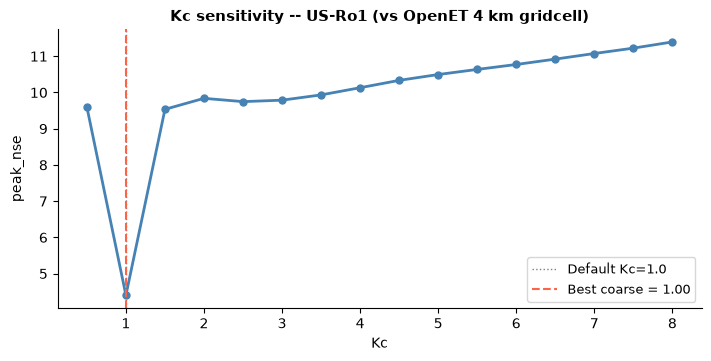

  Default (Kc=1.0) objective : 4.402
  Optimal Kc                 : 0.784
  Optimal objective          : 2.568


In [6]:
# ── B0: Configuration ─────────────────────────────────────────────────────────
OBJECTIVE   = "peak_nse"   # must match notebook 04's OBJECTIVE for a fair comparison in notebook 08
TEST_SITE   = "US-Ro1"
COARSE_LO   = 0.5
COARSE_HI   = 8.0
COARSE_STEP = 0.5
MAX_MULT    = 10.0

print(f"-- Single-site preview: {TEST_SITE} (objective='{OBJECTIVE}') --")

test_climate = climate_gee[climate_gee["site"] == TEST_SITE].copy()
test_params  = point_params_df[point_params_df["site"] == TEST_SITE].iloc[0]

test_openet = (
    openet_gridcell_df[openet_gridcell_df["site"] == TEST_SITE]
    [["date", ENSEMBLE_COL]]
    .dropna(subset=[ENSEMBLE_COL])
)
test_openet_cal = test_openet[
    (test_openet["date"] >= CAL_START) & (test_openet["date"] <= CAL_END)
]

test_obj_fn = make_site_objective_pm(test_climate, test_openet_cal, test_params, OBJECTIVE)

coarse_vals = np.arange(COARSE_LO, COARSE_HI + 0.01, COARSE_STEP)
coarse_obj  = [test_obj_fn(v) for v in coarse_vals]
best_coarse_idx = int(np.argmin(coarse_obj))

fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
ax.plot(coarse_vals, coarse_obj, color="steelblue", linewidth=2, marker="o", markersize=5)
ax.axvline(1.0, color="grey", linestyle=":", linewidth=1, label="Default Kc=1.0")
ax.axvline(coarse_vals[best_coarse_idx], color="tomato", linestyle="--", linewidth=1.5,
           label=f"Best coarse = {coarse_vals[best_coarse_idx]:.2f}")
ax.set_xlabel("Kc", fontsize=10)
ax.set_ylabel(f"{OBJECTIVE}", fontsize=10)
ax.set_title(f"Kc sensitivity -- {TEST_SITE} (vs OpenET 4 km gridcell)", fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
os.makedirs("../Data/open_et", exist_ok=True)
plt.savefig(f"../Data/open_et/kc_sensitivity_{TEST_SITE}_{OBJECTIVE}.png", dpi=150, bbox_inches="tight")
plt.show()

_lo = max(0.1, coarse_vals[best_coarse_idx] - COARSE_STEP)
_hi = min(MAX_MULT, coarse_vals[best_coarse_idx] + COARSE_STEP)
test_opt = minimize_scalar(test_obj_fn, bounds=(_lo, _hi), method="bounded", options={"xatol": 0.01})
best_kc = round(test_opt.x, 3)

print(f"  Default (Kc=1.0) objective : {test_obj_fn(1.0):.3f}")
print(f"  Optimal Kc                 : {best_kc}")
print(f"  Optimal objective          : {test_opt.fun:.3f}")


### B4: All-sites `Kc` calibration (incremental — only missing sites)

Same incremental-caching pattern as notebook 04: only sites missing from the
cache are (re-)optimized, so adding a new site later doesn't re-run everyone.
Cache filenames use a `_pm` suffix and `kc_` prefix to keep them distinct
from notebook 04's Oudin `pet_mult_*` caches.

In [7]:
KC_CACHE          = f"../Data/gridmet_cache/kc_site_{OBJECTIVE}.csv"
WBM_PM_OPT_CACHE  = f"../Data/gridmet_cache/wbm_results_site_cal_pm_{OBJECTIVE}.csv"
WBM_PM_MON_CACHE  = f"../Data/gridmet_cache/wbm_monthly_site_cal_pm_{OBJECTIVE}.csv"

all_calib_sites = point_params_df["site"].tolist()

existing_kc_df, missing_calib_sites = wbm.load_and_filter_missing(
    all_sites=all_calib_sites, cache_path=KC_CACHE, site_col="site",
)
existing_wbm_pm_opt_df, _ = wbm.load_and_filter_missing(
    all_sites=all_calib_sites, cache_path=WBM_PM_OPT_CACHE, site_col="site",
    parse_dates=["date"],
)

if not missing_calib_sites:
    print(f"All {len(all_calib_sites)} sites already calibrated in {KC_CACHE} -- skipping.")
    kc_df = existing_kc_df
    wbm_results_pm_opt = existing_wbm_pm_opt_df
else:
    print(f"Calibrating Kc for {len(missing_calib_sites)} new site(s): {missing_calib_sites}")
    print(f"({len(all_calib_sites) - len(missing_calib_sites)} site(s) already cached, skipped.)")

    kc_results = []
    wbm_frames_pm_opt = []

    for row in point_params_df.itertuples():
        site = row.site
        if site not in missing_calib_sites:
            continue

        site_climate = climate_gee[climate_gee["site"] == site].copy()
        site_openet_cal = (
            openet_gridcell_df[openet_gridcell_df["site"] == site]
            [["date", ENSEMBLE_COL]]
            .dropna(subset=[ENSEMBLE_COL])
        )
        site_openet_cal = site_openet_cal[
            (site_openet_cal["date"] >= CAL_START) & (site_openet_cal["date"] <= CAL_END)
        ]

        if site_climate.empty or site_openet_cal.empty:
            print(f"  {site:<12} -- skipping (no climate or calibration-period OpenET data)")
            kc_results.append({
                "site": site, "kc_opt": 1.0, "obj_default": np.nan,
                "obj_opt": np.nan, "improvement": np.nan, "status": "skipped",
            })
            continue

        print(f"  {site:<12} ...", end=" ")
        obj_fn = make_site_objective_pm(site_climate, site_openet_cal, row, OBJECTIVE)

        c_vals = np.arange(COARSE_LO, COARSE_HI + 0.01, COARSE_STEP)
        c_obj  = [obj_fn(v) for v in c_vals]
        best_i = int(np.argmin(c_obj))
        lo = max(0.1, c_vals[best_i] - COARSE_STEP)
        hi = min(MAX_MULT, c_vals[best_i] + COARSE_STEP)

        opt = minimize_scalar(obj_fn, bounds=(lo, hi), method="bounded", options={"xatol": 0.01})

        obj_def = round(obj_fn(1.0), 3)
        obj_opt = round(opt.fun, 3)
        kc_opt  = round(opt.x, 3)
        improvement = round(obj_def - obj_opt, 3)

        kc_results.append({
            "site": site, "kc_opt": kc_opt, "obj_default": obj_def,
            "obj_opt": obj_opt, "improvement": improvement, "status": "optimised",
        })
        print(f"Kc={kc_opt}  {OBJECTIVE}: {obj_def:.3f}->{obj_opt:.3f}  (delta={improvement:+.3f})")

        try:
            daily = run_wbm_with_spinup_pm(site_climate, row, kc_opt)
            daily["site"] = site
            daily["ecosystem"] = row.ecosystem
            daily["state"] = row.state
            daily["kc_opt"] = kc_opt
            wbm_frames_pm_opt.append(daily)
        except Exception as e:
            print(f"    WBM re-run failed: {e}")

    new_kc_df = pd.DataFrame(kc_results)
    print(f"\n-- Kc calibration summary ({OBJECTIVE}) -- new sites --")
    print(new_kc_df.to_string(index=False))

    if not wbm_frames_pm_opt:
        raise RuntimeError("WBM re-run produced no results for any missing site.")

    new_wbm_pm_opt_df = (
        pd.concat(wbm_frames_pm_opt, ignore_index=True)
        .sort_values(["site", "date"])
        .reset_index(drop=True)
    )

    kc_df = wbm.merge_and_save_cache(
        cache_path=KC_CACHE, existing_df=existing_kc_df,
        new_rows_df=new_kc_df, sort_cols=["site"],
    )
    wbm_results_pm_opt = wbm.merge_and_save_cache(
        cache_path=WBM_PM_OPT_CACHE, existing_df=existing_wbm_pm_opt_df,
        new_rows_df=new_wbm_pm_opt_df, sort_cols=["site", "date"],
    )
    print(f"\nSaved to {KC_CACHE} and {WBM_PM_OPT_CACHE}")

print(f"\nMean Kc       : {kc_df['kc_opt'].mean():.3f}")
print(f"Range         : {kc_df['kc_opt'].min():.3f} - {kc_df['kc_opt'].max():.3f}")
print(f"Sites improved: {(kc_df['improvement'] > 0).sum()} / {len(kc_df)}")

wbm_monthly_pm_opt = make_wbm_monthly(wbm_results_pm_opt)
wbm_monthly_pm_opt.to_csv(WBM_PM_MON_CACHE, index=False)
print(f"Saved to {WBM_PM_MON_CACHE}")


Calibrating Kc for 81 new site(s): ['US-A32', 'US-A74', 'US-ADR', 'US-ARM', 'US-Bi1', 'US-Bi2', 'US-CMW', 'US-CZ3', 'US-GLE', 'US-Hn2', 'US-Hn3', 'US-IB1', 'US-IB2', 'US-Jo2', 'US-KLS', 'US-KM4', 'US-Me2', 'US-Me6', 'US-MOz', 'US-NC2', 'US-NC3', 'US-NC4', 'US-NR1', 'US-Ro1', 'US-Ro2', 'US-Ro4', 'US-Ro5', 'US-Ro6', 'US-Rwf', 'US-Rws', 'US-Sne', 'US-SRG', 'US-SRM', 'US-Srr', 'US-SRS', 'US-Tw3', 'US-Twt', 'US-Var', 'US-WCr', 'US-Wkg', 'US-xAE', 'US-xDC', 'US-xDL', 'US-xDS', 'US-xJR', 'US-xNG', 'US-xNW', 'US-xRM', 'US-xSB', 'US-xSL', 'US-xST', 'US-xUN', 'US-xYE', 'Ellendale', 'manilacotton', 'stonevillesoy', 'US-OF1', 'US-OF2', 'US-OF4', 'US-OF6', 'S2', 'ALARC2_Smith6', 'Almond_High', 'Almond_Low', 'Almond_Med', 'JPL1_JV114', 'JPL1_Smith5', 'UA1_HartFarm', 'UA1_JV187', 'UA1_KN18', 'UA2_JV330', 'UA2_KN20', 'UA3_JV108', 'UA3_KN15', 'LYS_NE', 'LYS_NW', 'LYS_SE', 'LYS_SW', 'BAR012', 'RIP760', 'SLM001']
(0 site(s) already cached, skipped.)
  US-A32       ... Kc=0.72  peak_nse: 6.385->3.627  (de

### B4b: Per-ecosystem `Kc` calibration (single pooled `Kc` per ecosystem)

Mirrors notebook 04's per-ecosystem calibration exactly: pools every site in
an ecosystem's matched (calibration-period-only) observations into one
objective before fitting a single `Kc` for that land-cover type.

In [8]:
KC_ECO_CACHE         = f"../Data/gridmet_cache/kc_ecosystem_{OBJECTIVE}.csv"
WBM_PM_ECO_CACHE     = f"../Data/gridmet_cache/wbm_results_ecosystem_cal_pm_{OBJECTIVE}.csv"
WBM_PM_ECO_MON_CACHE = f"../Data/gridmet_cache/wbm_monthly_ecosystem_cal_pm_{OBJECTIVE}.csv"

ecosystems_all = sorted(point_params_df["ecosystem"].dropna().unique())

existing_kc_eco_df, missing_ecosystems = wbm.load_and_filter_missing(
    all_sites=ecosystems_all, cache_path=KC_ECO_CACHE, site_col="ecosystem",
)
existing_wbm_pm_eco_df, _ = wbm.load_and_filter_missing(
    all_sites=ecosystems_all, cache_path=WBM_PM_ECO_CACHE, site_col="ecosystem",
    parse_dates=["date"],
)

if not missing_ecosystems:
    kc_eco_df = existing_kc_eco_df
    wbm_results_pm_eco = existing_wbm_pm_eco_df
else:
    kc_eco_results, wbm_frames_pm_eco = [], []

    for eco in missing_ecosystems:
        eco_sites_df = point_params_df[point_params_df["ecosystem"] == eco]

        eco_climate_by_site, eco_openet_cal_by_site, eco_params_by_site = {}, {}, {}
        for row in eco_sites_df.itertuples():
            site = row.site
            site_climate = climate_gee[climate_gee["site"] == site].copy()
            site_openet_cal = (
                openet_gridcell_df[openet_gridcell_df["site"] == site]
                [["date", ENSEMBLE_COL]]
                .dropna(subset=[ENSEMBLE_COL])
            )
            site_openet_cal = site_openet_cal[
                (site_openet_cal["date"] >= CAL_START) & (site_openet_cal["date"] <= CAL_END)
            ]
            if site_climate.empty or site_openet_cal.empty:
                continue
            eco_climate_by_site[site] = site_climate
            eco_openet_cal_by_site[site] = site_openet_cal
            eco_params_by_site[site] = row

        if not eco_climate_by_site:
            print(f"  {eco:<25} -- skipping (no usable sites)")
            kc_eco_results.append({
                "ecosystem": eco, "n_sites": 0, "kc_opt": 1.0,
                "obj_default": np.nan, "obj_opt": np.nan,
                "improvement": np.nan, "status": "skipped",
            })
            continue

        print(f"  {eco:<25} ({len(eco_climate_by_site)} site(s)) ...", end=" ")
        obj_fn = make_ecosystem_objective_pm(
            eco_climate_by_site, eco_openet_cal_by_site, eco_params_by_site, OBJECTIVE
        )

        c_vals = np.arange(COARSE_LO, COARSE_HI + 0.01, COARSE_STEP)
        c_obj  = [obj_fn(v) for v in c_vals]
        best_i = int(np.argmin(c_obj))
        lo = max(0.1, c_vals[best_i] - COARSE_STEP)
        hi = min(MAX_MULT, c_vals[best_i] + COARSE_STEP)

        opt = minimize_scalar(obj_fn, bounds=(lo, hi), method="bounded", options={"xatol": 0.01})

        obj_def = round(obj_fn(1.0), 3)
        obj_opt = round(opt.fun, 3)
        kc_opt  = round(opt.x, 3)
        improvement = round(obj_def - obj_opt, 3)

        kc_eco_results.append({
            "ecosystem": eco, "n_sites": len(eco_climate_by_site), "kc_opt": kc_opt,
            "obj_default": obj_def, "obj_opt": obj_opt,
            "improvement": improvement, "status": "optimised",
        })
        print(f"Kc={kc_opt}  {OBJECTIVE}: {obj_def:.3f}->{obj_opt:.3f}  (delta={improvement:+.3f})")

        for site, site_climate in eco_climate_by_site.items():
            params_row = eco_params_by_site[site]
            try:
                daily = run_wbm_with_spinup_pm(site_climate, params_row, kc_opt)
                daily["site"] = site
                daily["ecosystem"] = eco
                daily["state"] = params_row.state
                daily["kc_opt"] = kc_opt
                wbm_frames_pm_eco.append(daily)
            except Exception as e:
                print(f"    WBM re-run failed for {site}: {e}")

    new_kc_eco_df = pd.DataFrame(kc_eco_results)
    print(f"\n-- Ecosystem Kc calibration summary ({OBJECTIVE}) -- new ecosystems --")
    print(new_kc_eco_df.to_string(index=False))

    if not wbm_frames_pm_eco:
        raise RuntimeError("WBM re-run produced no results for any missing ecosystem.")

    new_wbm_pm_eco_df = (
        pd.concat(wbm_frames_pm_eco, ignore_index=True)
        .sort_values(["site", "date"])
        .reset_index(drop=True)
    )

    missing_eco_sites = point_params_df[
        point_params_df["ecosystem"].isin(missing_ecosystems)
    ]["site"].tolist()
    if existing_wbm_pm_eco_df is not None and not existing_wbm_pm_eco_df.empty:
        existing_wbm_pm_eco_df = existing_wbm_pm_eco_df[
            ~existing_wbm_pm_eco_df["site"].isin(missing_eco_sites)
        ]

    kc_eco_df = wbm.merge_and_save_cache(
        cache_path=KC_ECO_CACHE, existing_df=existing_kc_eco_df,
        new_rows_df=new_kc_eco_df, sort_cols=["ecosystem"],
    )
    wbm_results_pm_eco = wbm.merge_and_save_cache(
        cache_path=WBM_PM_ECO_CACHE, existing_df=existing_wbm_pm_eco_df,
        new_rows_df=new_wbm_pm_eco_df, sort_cols=["site", "date"],
    )
    print(f"\nSaved to {KC_ECO_CACHE} and {WBM_PM_ECO_CACHE}")

print(f"\nEcosystems fit: {len(kc_eco_df)}")
print(kc_eco_df.to_string(index=False))

wbm_monthly_pm_eco = make_wbm_monthly(wbm_results_pm_eco)
wbm_monthly_pm_eco.to_csv(WBM_PM_ECO_MON_CACHE, index=False)
print(f"Saved to {WBM_PM_ECO_MON_CACHE}")

# ── Cache the objective name so downstream notebooks (08) know which Kc fit
# to load, the same way notebook 04 caches last_objective.txt. Both notebooks
# should agree on OBJECTIVE, so this just re-writes the same value (a mismatch
# here would mean the two calibrations used different objectives -- worth
# checking manually if that ever happens).
with open("../Data/gridmet_cache/last_objective_pm.txt", "w") as f:
    f.write(OBJECTIVE)
print(f"\nSaved objective name '{OBJECTIVE}' to last_objective_pm.txt")


  Croplands                 (40 site(s)) ... Kc=0.673  peak_nse: 11.483->10.590  (delta=+0.893)
  Evergreen Forests         (7 site(s)) ... Kc=0.594  peak_nse: 36.853->32.534  (delta=+4.319)
  Grasslands                (10 site(s)) ... Kc=0.766  peak_nse: 5.682->5.256  (delta=+0.426)
  Mixed Forests             (4 site(s)) ... Kc=0.938  peak_nse: 2.320->2.250  (delta=+0.070)
  Shrublands                (8 site(s)) ... Kc=0.534  peak_nse: 8.085->7.418  (delta=+0.667)
  Wetland/Riparian          (3 site(s)) ... Kc=0.381  peak_nse: 58.315->55.085  (delta=+3.230)

-- Ecosystem Kc calibration summary (peak_nse) -- new ecosystems --
        ecosystem  n_sites  kc_opt  obj_default  obj_opt  improvement    status
        Croplands       40   0.673       11.483   10.590        0.893 optimised
Evergreen Forests        7   0.594       36.853   32.534        4.319 optimised
       Grasslands       10   0.766        5.682    5.256        0.426 optimised
    Mixed Forests        4   0.938        2.3

### Summary & suggested follow-ups

This calibrates Penman-Monteith's crop coefficient (`Kc`) the same way
notebook 04 calibrates Oudin's PET multiplier: per-site and per-ecosystem,
fit only on the 2016–2021 calibration period, so notebook 08 can score
both variants on a genuinely held-out 2022–2023 test period. Cached
outputs: `kc_site_{OBJECTIVE}.csv` / `kc_ecosystem_{OBJECTIVE}.csv` (the
fitted `Kc` values) and `wbm_results_site_cal_pm_{OBJECTIVE}.csv` /
`wbm_results_ecosystem_cal_pm_{OBJECTIVE}.csv` (full daily WBM re-runs,
matching notebook 04's naming convention with a `_pm` tag).

**Natural follow-ups:**
- Notebook 08 should add these two variants to its six-way comparison against
  OpenET and flux towers, using the same held-out design, so the nationwide
  recommendation can weigh calibrated Penman-Monteith against calibrated
  Oudin on equal footing.
- If per-site-calibrated Penman-Monteith turns out to be statistically
  indistinguishable from per-site-calibrated Oudin (same paired
  Wilcoxon-test approach already used in the report), Penman-Monteith's
  practical advantage (still needs future-climate compatibility either way,
  once calibrated) may no longer be the deciding factor -- worst-case
  robustness and calibration-data availability would matter more.
- Adding real gridMET relative humidity (rather than the `e_a = e_tmin`
  fallback) before calibrating `Kc` would separate "Penman-Monteith's true
  accuracy once properly calibrated" from "Kc absorbing bias introduced by
  the vapor-pressure approximation."
